# Method comparison — Base / CDQ / MICE / Biased-cost

Standalone: no imports from `plots/` or the other notebooks. Each method comes from its **own
sweep**; for each one the notebook picks the best config by a metric you choose, then draws a
single 1x4 comparison.

| method | sweep | algo | grid |
|---|---|---|---|
| Base | `x1747wy1` | CPO | adv-est x critic.lr (4 configs x 5 seeds) |
| CDQ | `zijt7hxr` | CPO + `ensemble-method=cdq` | adv-est x critic.lr (4 x 5) |
| MICE | `2pezmiuh` | MICE | intrinsic_factor x update-iters x critic.lr (27 x ~5) |
| Biased-cost | `sjxtyp2p` | MICE + constant cost | update-iters x constant-cost x decay-rate x critic.lr (36 x ~5) |

### The four columns

1. **Performance** — final `EpRet` against average episode cost, one standard-error ellipse per method
2. **Estimation error** — `pred - true` on the probe states, across training
3. **Correlation (cost)** — `PooledMC/Correlation_c`, across training
4. **Signed error by bin** — Base and MICE only, split by the reference value:
   low $< \gamma^{500} \leq$ intermediate $< \gamma^{5} \leq$ high

Colour means **method** in every panel; in column 4 the line style means the bin.

### Config selection

`SELECT_METRIC` picks the config per sweep, over that sweep's own grid:

| metric | score per config | best |
|---|---|---|
| `ratio` *(default)* | per-seed `EpRet / avg_ep_cost`, averaged over seeds | max |
| `EpRet` | mean final `EpRet` | max |
| `avg_ep_cost` | mean `TotalCost / episodes` | min |

`avg_ep_cost = TotalCost / (TotalEnvSteps / EpLen)` — i.e. `TotalCost / (#epochs x 20)` for a
full-length run, but computed from each run's *actual* steps so truncated runs stay comparable.

## 1. Config

In [45]:
import csv
import pathlib
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

REPO = pathlib.Path.cwd().resolve()
while not (REPO / "omnisafe").is_dir() and not (REPO / "plots").is_dir():
    if REPO.parent == REPO:
        raise RuntimeError("could not find the MICE repo root")
    REPO = REPO.parent

DATA_DIR = REPO / "figs" / "method_comparison"
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ENTITY_PROJECT = "liam-paull/calibration_rl"

# name -> sweep id.  Order fixes plotting order and legend order.
METHODS = [("Base", "x1747wy1"),
           ("CDQ", "zijt7hxr"),
           ("MICE", "2pezmiuh"),
           ("Biased-cost", "sjxtyp2p")]

# Column 4 needs the eval_data probe artifacts; CDQ's sweep does not log them.
BIN_METHODS = ["Base", "MICE"]

SELECT_METRIC = "ratio"        # "ratio" | "EpRet" | "avg_ep_cost"

GAMMA, COST_LIMIT = 0.99, 10.0
T_LOW, T_HIGH = GAMMA ** 500, GAMMA ** 5      # value-bin edges
MIN_STEPS_FRAC = 0.95          # drop runs that stopped short of the sweep's full length

HISTORY_KEYS = ["TotalEnvSteps", "Metrics/EpRet", "Metrics/EpCost",
                "PooledMC/Correlation_c", "PooledMC/EstimationError_c"]
# config keys that are never part of a sweep's grid
IGNORE_PARAMS = {"device", "env-id", "algo", "seed"}

print("repo:", REPO, "\ncache:", DATA_DIR)

repo: /home/kaustubh/projects/conservatism_rl/MICE 
cache: /home/kaustubh/projects/conservatism_rl/MICE/figs/method_comparison


## 2. Style

`STYLE` and `TEXT` drive every mark and string. Titles are deliberately terse; legend and
label type is large, as this figure is meant to be read at a glance.

In [57]:
STYLE = {
    # Okabe-Ito, four distinguishable hues; colour means METHOD in every panel
    "method": {"Base": "#0072B2", "CDQ": "#009E73",
               "MICE": "#D55E00", "Biased-cost": "#CC79A7"},
    # column 4: the value bin is encoded twice over -- line style AND marker shape -- so the
    # three bins stay separable where the curves cross.
    "bin_style": ["-", (0, (6, 3)), (0, (1, 2.2))],
    "bin_marker": ["o", "s", "^"],          # circle / square / triangle
    "ink": {"title": "#1a1a1a", "label": "#5a5a5a", "spine": "#909090",
            "tick": "#8a8a8a", "grid": "#d8d8d8", "rule": "#5a5a5a"},
    "font": {"family": "DejaVu Sans", "title": 30, "label": 30, "tick": 20,
             "legend": 32, "note": 21},
    "line": {"width": 2.6, "marker": 6, "band_alpha": 0.18,
             "grid": 1.0, "spine": 1.0, "tick_len": 3.6, "tick_width": 1.0,
             "rule_width": 1.7, "rule_dash": (0, (5, 3)),
             "ellipse_alpha": 0.20, "ellipse_edge": 2.2, "mean_marker": 15,
             "bin_marker_size": 9,
             "seed_marker": 7, "seed_alpha": 0.55},
    "panel": {"w": 5.20, "h": 4.40, "wgap": 1.20, "hgap": 1.45,
              "left": 1.85, "right": 0.15, "top": 0.70, "bottom": 1.15},
    "band": "sem",
    "dpi": 300, "pad_inches": 0.1,
    "xticks": [3e4, 1e5, 3e5, 1e6, 3e6, 1e7],
}

TEXT = {
    "titles": ["Performance", "Estimation error", "Correlation (cost)", "Signed error by value group"],
    "xlabel_steps": "Total env steps",
    "perf_x": "Avg episode cost",
    "perf_y": "Episode return",
    "err_y": r"$\hat V_c - \tilde V_c$",
    "corr_y": r"Corr($\hat V_c$, $\tilde V_c$)",
    "bin_y": r"$\hat V_c - \tilde V_c$",
    "cost_limit": "cost limit",
    "bins": ["low", "intermediate", "high"],
    "bin_defs": [r"low: $\tilde V_c < \gamma^{500}$",
                 r"intermediate: $\gamma^{500} \leq \tilde V_c < \gamma^{5}$",
                 r"high: $\tilde V_c \geq \gamma^{5}$"],
}


def apply_style():
    """Push STYLE into rcParams. Re-run after editing STYLE."""
    f, l, ink = STYLE["font"], STYLE["line"], STYLE["ink"]
    mpl.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": STYLE["dpi"],
        "font.family": "sans-serif", "font.sans-serif": [f["family"]], "font.size": f["tick"],
        "axes.titlesize": f["title"], "axes.titlecolor": ink["title"], "axes.titlepad": 10,
        "axes.labelsize": f["label"], "axes.labelcolor": ink["label"],
        "axes.edgecolor": ink["spine"], "axes.linewidth": l["spine"],
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
        "grid.color": ink["grid"], "grid.linewidth": l["grid"], "grid.alpha": 1.0,
        "xtick.labelsize": f["tick"], "ytick.labelsize": f["tick"],
        "xtick.color": ink["tick"], "ytick.color": ink["tick"],
        "xtick.labelcolor": ink["label"], "ytick.labelcolor": ink["label"],
        "xtick.direction": "out", "ytick.direction": "out",
        "xtick.major.size": l["tick_len"], "ytick.major.size": l["tick_len"],
        "xtick.major.width": l["tick_width"], "ytick.major.width": l["tick_width"],
        "xtick.minor.visible": False, "ytick.minor.visible": False,
        "legend.fontsize": f["legend"], "legend.frameon": False,
    })


apply_style()
MCOLOR = STYLE["method"]
print("style applied |", MCOLOR)

style applied | {'Base': '#0072B2', 'CDQ': '#009E73', 'MICE': '#D55E00', 'Biased-cost': '#CC79A7'}


## 3. Utilities

All helpers at once: **3.1** fetching and caching, **3.2** config selection, **3.3** probe
loading and binning, **3.4** drawing primitives.

### 3.1 Fetching and caching

In [58]:
def save_csv(df, path):
    """Temp + rename, so an interrupted run leaves no half-written cache."""
    tmp = str(path) + ".tmp"
    df.to_csv(tmp, index=False)
    pathlib.Path(tmp).replace(path)


def to_numeric(df, cols):
    """wandb returns sparsely-logged columns as dtype=object; CSV round-trips them to float."""
    for c in cols:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def fetch_sweep(sweep_id):
    """One row per run: its grid parameters and end-of-training summary."""
    import wandb
    api = wandb.Api(timeout=180)
    sweep = api.sweep(f"{ENTITY_PROJECT}/{sweep_id}")
    params = [k for k in sweep.config.get("parameters", {}) if k not in IGNORE_PARAMS]
    rows = []
    for r in sweep.runs:
        c = r.config
        d = {k: c.get(k) for k in params}
        d.update(run_id=r.id, state=r.state, seed=c.get("seed"),
                 EpRet=r.summary.get("Metrics/EpRet"),
                 EpLen=r.summary.get("Metrics/EpLen"),
                 TotalCost=r.summary.get("Metrics/TotalCost"),
                 TotalEnvSteps=r.summary.get("TotalEnvSteps"))
        rows.append(d)
    df = pd.DataFrame(rows)
    df.attrs["params"] = params
    return df


def fetch_history(run_ids):
    """Per-epoch curves for a handful of runs."""
    import wandb
    api = wandb.Api(timeout=180)
    out = []
    for i, rid in enumerate(run_ids, 1):
        h = api.run(f"{ENTITY_PROJECT}/{rid}").history(keys=HISTORY_KEYS, samples=100_000)
        h["run_id"] = rid
        out.append(h)
        print(f"    {i}/{len(run_ids)} {rid}", end="\r", flush=True)
    return pd.concat(out, ignore_index=True)


def download_probes(run_ids_by_seed, dest, workers=5):
    """eval_data pickles into dest/seed<N>/epoch_*.pkl, skipping files already present."""
    import wandb

    def one(run_id, seed):
        api = wandb.Api(timeout=180)               # one Api per thread
        d = dest / f"seed{seed}"
        d.mkdir(parents=True, exist_ok=True)
        got = 0
        for art in api.run(f"{ENTITY_PROJECT}/{run_id}").logged_artifacts():
            if art.type != "eval_data":
                continue
            for f in art.files():
                if f.name.lower().endswith(".pkl") and not (d / f.name).exists():
                    f.download(root=str(d), replace=False)
                    got += 1
        return seed, got

    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = {ex.submit(one, rid, sd): sd for sd, rid in run_ids_by_seed.items()}
        for i, fut in enumerate(as_completed(futs), 1):
            sd, got = fut.result()
            print(f"    [{i}/{len(futs)}] seed{sd}: +{got} new", flush=True)


def probe_status(dest, seeds):
    """Complete only if every seed is present with the same, non-zero checkpoint count."""
    counts = {s: len(list((dest / f"seed{s}").glob("epoch_*.pkl")))
              if (dest / f"seed{s}").is_dir() else 0 for s in seeds}
    if not counts or min(counts.values()) == 0:
        return False, f"missing seeds {[s for s, n in counts.items() if n == 0]}"
    if len(set(counts.values())) > 1:
        return False, f"uneven checkpoint counts {sorted(set(counts.values()))}"
    return True, f"{len(counts)} seeds x {next(iter(counts.values()))} checkpoints"

### 3.2 Config selection

Each sweep has its own grid, so the grid keys are read off the sweep rather than hard-coded:
every parameter that actually varies, minus the seed. Runs that crashed or stopped short are
dropped before scoring, and the drop is reported.

In [59]:
def grid_keys(df):
    """The sweep's grid: parameters that vary across runs, excluding the seed."""
    return [k for k in df.attrs["params"] if df[k].astype(str).nunique() > 1]


def usable(df):
    """Finished runs that reached (nearly) the sweep's full length."""
    full = df.TotalEnvSteps.max()
    keep = (df.state == "finished") & (df.TotalEnvSteps >= MIN_STEPS_FRAC * full)
    dropped = df[~keep]
    if len(dropped):
        why = dropped.assign(short=dropped.TotalEnvSteps < MIN_STEPS_FRAC * full)
        print(f"    dropped {len(dropped)} runs "
              f"({int((why.state != 'finished').sum())} unfinished, "
              f"{int(why.short.sum())} short of {MIN_STEPS_FRAC:.0%} of {full/1e6:.2f}M)")
    return df[keep].copy()


def score_configs(df):
    """Per-config scores across seeds.

    avg_ep_cost uses each run's own step count, so a truncated run is not credited with a
    lower total cost simply for having run less.
    """
    d = usable(df)
    d["episodes"] = d.TotalEnvSteps / d.EpLen
    d["avg_ep_cost"] = d.TotalCost / d.episodes
    d["ratio"] = d.EpRet / d.avg_ep_cost
    keys = grid_keys(df)
    g = (d.groupby([d[k].astype(str) for k in keys] if keys else [lambda _: 0])
         .agg(ratio=("ratio", "mean"), EpRet=("EpRet", "mean"),
              avg_ep_cost=("avg_ep_cost", "mean"), n_seeds=("seed", "size"))
         .reset_index())
    g.attrs["keys"] = keys
    return g, d


def best_config(scores, metric):
    """Winning row: max for ratio/EpRet, min for avg_ep_cost."""
    if metric not in ("ratio", "EpRet", "avg_ep_cost"):
        raise ValueError(f"unknown metric {metric!r}")
    idx = scores[metric].idxmin() if metric == "avg_ep_cost" else scores[metric].idxmax()
    return scores.loc[idx]


def select_runs(df, runs, best):
    """The rows of `runs` belonging to the winning config."""
    keys = grid_keys(df)
    m = np.ones(len(runs), bool)
    for k in keys:
        m &= runs[k].astype(str).values == best[k]
    return runs[m].sort_values("seed")

### 3.3 Probes and value bins

In [60]:
def load_probe_tree(dest, seeds):
    """Stack a method's probe checkpoints: (n_seeds, n_checkpoints, n_probes[, K])."""
    per = []
    for s in seeds:
        pts = []
        for path in sorted((dest / f"seed{s}").glob("epoch_*.pkl")):
            with open(path, "rb") as fh:
                d = pickle.load(fh)
            raw = d["pooled"]["raw"]
            pts.append({"epoch": int(d["epoch"]),
                        "pred": np.asarray(raw["c"]["pred"], float),
                        "G": np.asarray(raw["c"]["returns"], float)})
        per.append(sorted(pts, key=lambda p: p["epoch"]))
    n = min(len(p) for p in per)
    per = [p[:n] for p in per]
    return {"epochs": np.array([p["epoch"] for p in per[0]], int),
            "pred": np.stack([[c["pred"] for c in s] for s in per]),
            "G": np.stack([[c["G"] for c in s] for s in per])}


def value_bins(v):
    """Masks for low / intermediate / high reference value."""
    return [v < T_LOW, (v >= T_LOW) & (v < T_HIGH), v >= T_HIGH]


def signed_error_by_bin(pred, G):
    """Mean (pred - reference) within each value bin, for one checkpoint of one seed."""
    gbar = G.mean(-1)
    e = pred - gbar
    return [float(e[m].mean()) if m.any() else np.nan for m in value_bins(gbar)]

### 3.4 Drawing primitives

In [61]:
def make_axes(ncols, nrows=1, legend_in=0.0, panel_w=None, panel_h=None):
    """Figure laid out from STYLE['panel'], in inches; legend_in reserves space below."""
    P = STYLE["panel"]
    w, h = panel_w or P["w"], panel_h or P["h"]
    left, bottom = P["left"], P["bottom"] + legend_in
    fig_w = left + ncols * w + (ncols - 1) * P["wgap"] + P["right"]
    fig_h = P["top"] + nrows * h + (nrows - 1) * P["hgap"] + bottom
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    fig.subplots_adjust(left=left / fig_w, right=1 - P["right"] / fig_w,
                        top=1 - P["top"] / fig_h, bottom=bottom / fig_h,
                        wspace=P["wgap"] / w, hspace=P["hgap"] / h)
    return fig, (axes[0] if nrows == 1 else axes)


def fmt_steps(v, _=None):
    return f"{v/1e6:g}M" if v >= 1e6 else f"{v/1e3:g}k"


def log_steps(ax, x_first, x_last, xlabel=True):
    ax.set_xscale("log")
    ax.set_xticks(STYLE["xticks"])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlim(x_first, x_last)
    if xlabel:
        ax.set_xlabel(TEXT["xlabel_steps"])


def spread(M, how=None):
    """Seed mean and band half-width: standard error (default) or standard deviation."""
    M = np.asarray(M, float)
    m = np.nanmean(M, 0)
    sd = np.nanstd(M, 0, ddof=1) if M.shape[0] > 1 else np.zeros(M.shape[1])
    if (how or STYLE["band"]) == "sem":
        return m, sd / np.sqrt(np.maximum(np.sum(np.isfinite(M), 0), 1))
    return m, sd


def band(ax, x, M, color, ls="-", lw=None, zorder=3, marker=None, markevery=None,
         ms=None):
    L = STYLE["line"]
    m, e = spread(M)
    ax.plot(x, m, color=color, lw=lw or L["width"], ls=ls, zorder=zorder,
            marker=marker, markevery=markevery, markersize=ms or L["bin_marker_size"],
            markeredgecolor="white", markeredgewidth=0.9)
    ax.fill_between(x, m - e, m + e, color=color, alpha=L["band_alpha"], lw=0,
                    zorder=zorder - 1)
    return m


def sem_ellipse(ax, x, y, color):
    """Standard-error ellipse of the mean of the (x, y) seed points.

    The covariance of the points describes seed-to-seed spread; dividing it by n turns that
    into the sampling covariance of the mean, so the ellipse is a 1-s.e. region for where the
    method sits -- not a region containing the seeds.
    """
    n = len(x)
    if n < 3:
        return
    cov = np.cov(x, y) / n
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    if not np.all(np.isfinite(vals)) or (vals <= 0).any():
        return
    w, h = 2 * np.sqrt(vals)
    ang = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    L = STYLE["line"]
    ax.add_patch(Ellipse((np.mean(x), np.mean(y)), width=w, height=h, angle=ang,
                         facecolor=color, edgecolor=color, alpha=L["ellipse_alpha"],
                         linewidth=L["ellipse_edge"], zorder=3))


def legend_below(fig, entries, ncol=4, y=0.012):
    fig.legend([h for h, _ in entries], [l for _, l in entries], loc="lower center",
               ncol=ncol, frameon=False, fontsize=STYLE["font"]["legend"],
               bbox_to_anchor=(0.5, y))


def line_key(color, ls="-", lw=None, marker=None):
    return Line2D([], [], color=color, lw=lw or STYLE["line"]["width"], ls=ls,
                  marker=marker, markersize=STYLE["line"]["bin_marker_size"],
                  markeredgecolor="white", markeredgewidth=0.9)


def dot_key(color):
    return Line2D([], [], color=color, marker="o", ls="none",
                  markersize=STYLE["line"]["marker"] + 4, markeredgewidth=0)


def save(fig, stem, formats=("png", "pdf")):
    for ext in formats:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=STYLE["dpi"], bbox_inches="tight",
                    pad_inches=STYLE["pad_inches"], facecolor="white")
    print("saved:", stem, "/".join(formats))


def show(*stems, width=1400):
    try:
        from IPython.display import Image, display
    except ImportError:
        return
    for s in stems:
        display(Image(filename=str(FIG_DIR / f"{s}.png"), width=width))

## 4. Load and select

Per method: fetch the sweep summary, score its grid, pick the winner by `SELECT_METRIC`,
then fetch that config's per-seed curves. Everything is cached.

In [62]:
SWEEPS, SCORES, RUNS, BEST, HIST = {}, {}, {}, {}, {}

for name, sid in METHODS:
    csv_path = DATA_DIR / f"summary_{sid}.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.attrs["params"] = [c for c in df.columns if c not in
                              ("run_id", "state", "seed", "EpRet", "EpLen",
                               "TotalCost", "TotalEnvSteps")]
    else:
        print(f"{name}: fetching sweep {sid}")
        df = fetch_sweep(sid)
        save_csv(df, csv_path)
    df = to_numeric(df, ["EpRet", "EpLen", "TotalCost", "TotalEnvSteps", "seed"])
    SWEEPS[name] = df

    print(f"\n{name} ({sid}): {len(df)} runs, grid {grid_keys(df)}")
    scores, runs = score_configs(df)
    best = best_config(scores, SELECT_METRIC)
    SCORES[name], RUNS[name], BEST[name] = scores, runs, best
    cfg = {k: best[k] for k in scores.attrs["keys"]}
    print(f"    {len(scores)} configs -> best by {SELECT_METRIC}: {cfg}")
    print(f"    EpRet {best.EpRet:.2f} | avg ep cost {best.avg_ep_cost:.2f} | "
          f"ratio {best.ratio:.3f} | {int(best.n_seeds)} seeds")

    sel = select_runs(df, runs, best)
    hist_path = DATA_DIR / f"history_{sid}.csv"
    if hist_path.exists():
        h = pd.read_csv(hist_path)
    else:
        print(f"    fetching history for {len(sel)} runs")
        h = fetch_history(sel.run_id.tolist())
        save_csv(h, hist_path)
    HIST[name] = to_numeric(h, HISTORY_KEYS).merge(
        sel[["run_id", "seed"]], on="run_id", how="left")

X_FIRST = min(h.TotalEnvSteps.min() for h in HIST.values())
X_LAST = max(h.TotalEnvSteps.max() for h in HIST.values())
print(f"\nsteps {X_FIRST:,.0f} -> {X_LAST:,.0f}")


Base (x1747wy1): 20 runs, grid ['adv-estimation-method', 'model-cfgs.critic.lr']
    4 configs -> best by ratio: {'adv-estimation-method': 'gae', 'model-cfgs.critic.lr': '0.0003'}
    EpRet 16.94 | avg ep cost 12.72 | ratio 1.333 | 5 seeds

CDQ (zijt7hxr): 20 runs, grid ['adv-estimation-method', 'model-cfgs.critic.lr']
    4 configs -> best by ratio: {'adv-estimation-method': 'plain', 'model-cfgs.critic.lr': '0.0003'}
    EpRet 17.18 | avg ep cost 12.85 | ratio 1.337 | 5 seeds

MICE (2pezmiuh): 135 runs, grid ['algo-cfgs.intrinsic_factor', 'algo-cfgs.update-iters', 'model-cfgs.critic.lr']
    dropped 1 runs (1 unfinished, 1 short of 95% of 10.24M)
    27 configs -> best by ratio: {'algo-cfgs.intrinsic_factor': '10', 'algo-cfgs.update-iters': '2', 'model-cfgs.critic.lr': '0.0001'}
    EpRet 11.43 | avg ep cost 8.94 | ratio 1.280 | 5 seeds

Biased-cost (sjxtyp2p): 180 runs, grid ['algo-cfgs.update-iters', 'constant-cost', 'cost-decay-rate', 'model-cfgs.critic.lr']
    dropped 5 runs (5 

### 4.1 Probe artifacts for column 4

Only the two methods column 4 compares. CDQ's sweep logs no `eval_data`, which is why it is
not in that panel.

In [63]:
PROBE = {}
for name in BIN_METHODS:
    sid = dict(METHODS)[name]
    sel = select_runs(SWEEPS[name], RUNS[name], BEST[name])
    seeds = sel.seed.astype(int).tolist()
    dest = DATA_DIR / f"probes_{sid}"
    ok, detail = probe_status(dest, seeds)
    if not ok:
        print(f"{name}: {detail}; downloading -> {dest}")
        download_probes(dict(zip(seeds, sel.run_id)), dest)
        ok, detail = probe_status(dest, seeds)
        if not ok:
            raise RuntimeError(f"{name}: probes still incomplete -- {detail}")
    print(f"{name}: {detail}")
    PROBE[name] = load_probe_tree(dest, seeds)
    PROBE[name]["steps"] = (PROBE[name]["epochs"] + 1) * 20_000
    print(f"    probes {PROBE[name]['G'].shape[2]} x K={PROBE[name]['G'].shape[3]}")

Base: 5 seeds x 37 checkpoints
    probes 102 x K=10
MICE: 5 seeds x 29 checkpoints
    probes 102 x K=10


## 5. The comparison

1. **Performance** — per-seed finals with a 1-s.e. ellipse per method; the dashed rule is the
   cost limit. Left and up is better.
2. **Estimation error** — `pred - true`. Above zero the critic over-predicts cost.
3. **Correlation (cost)** — does the critic rank states correctly, regardless of scale.
4. **Signed error by bin** — Base vs MICE, split by the reference value. Colour is the
   method, line style is the bin.

/tmp/ipykernel_368284/1489639388.py:32: RuntimeWarning: Mean of empty slice
  m = np.nanmean(M, 0)
/home/kaustubh/miniforge3/envs/omnisafe/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


saved: method_comparison_ratio png/pdf


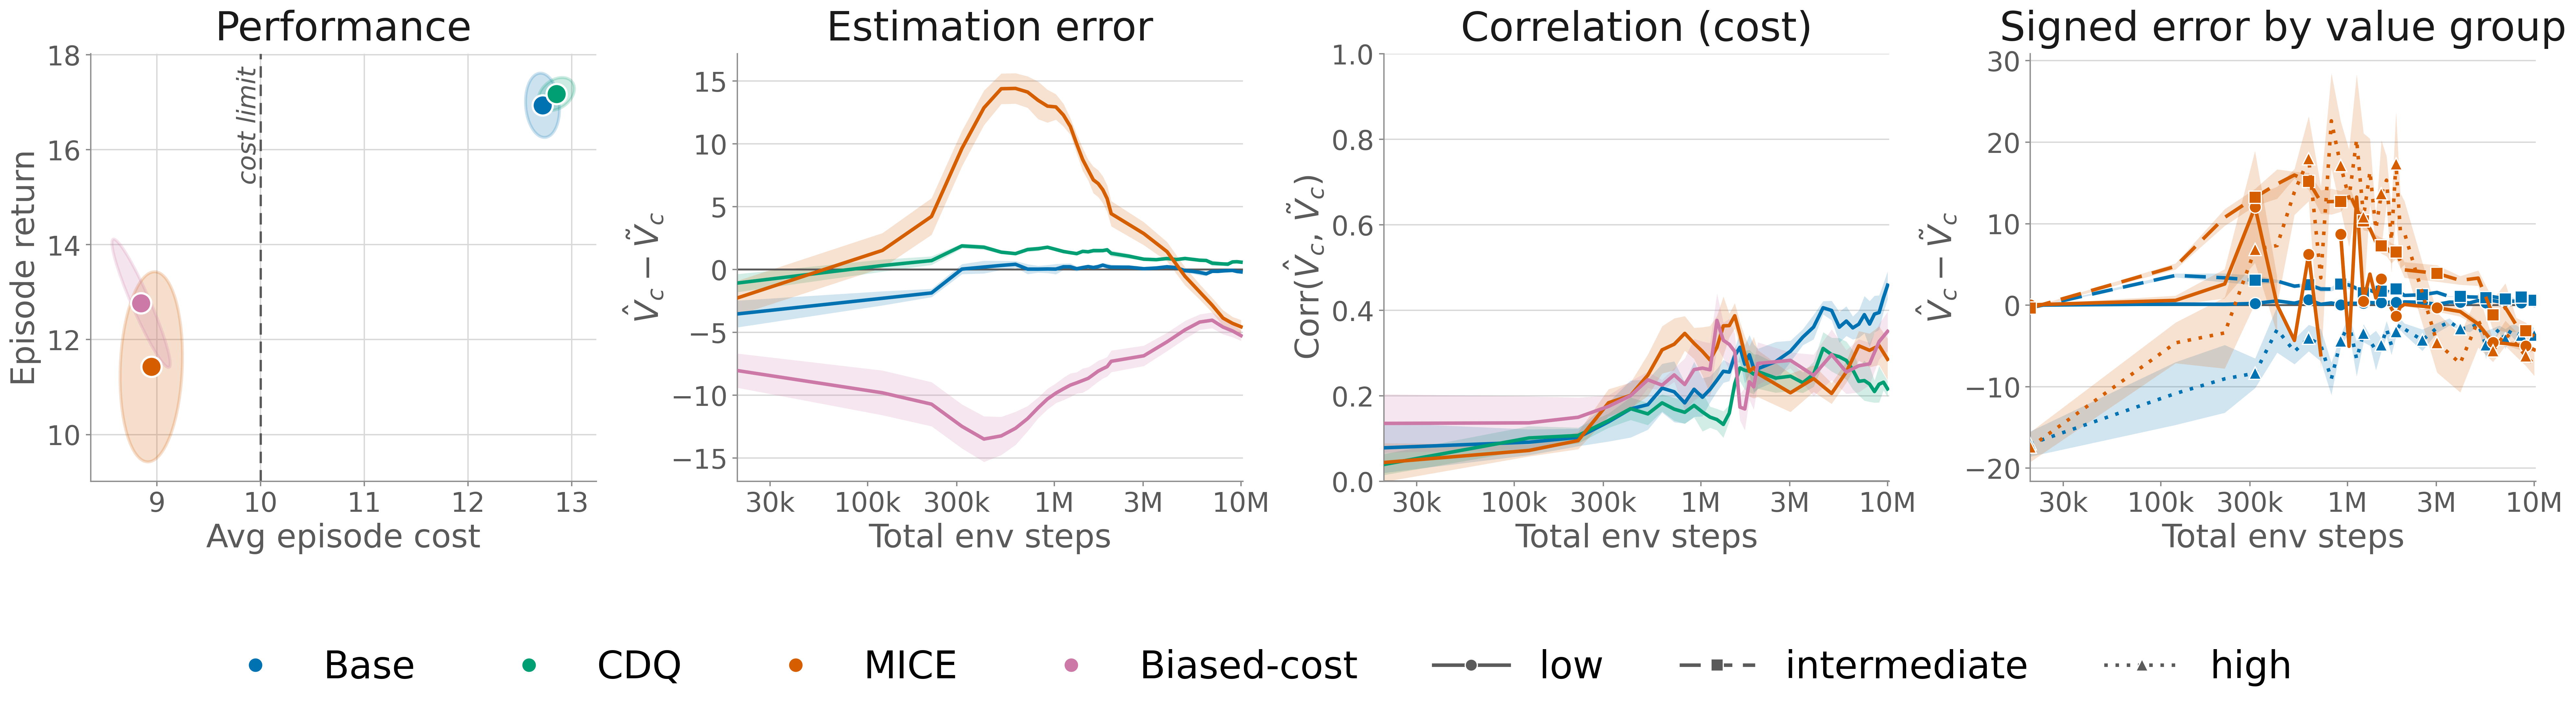

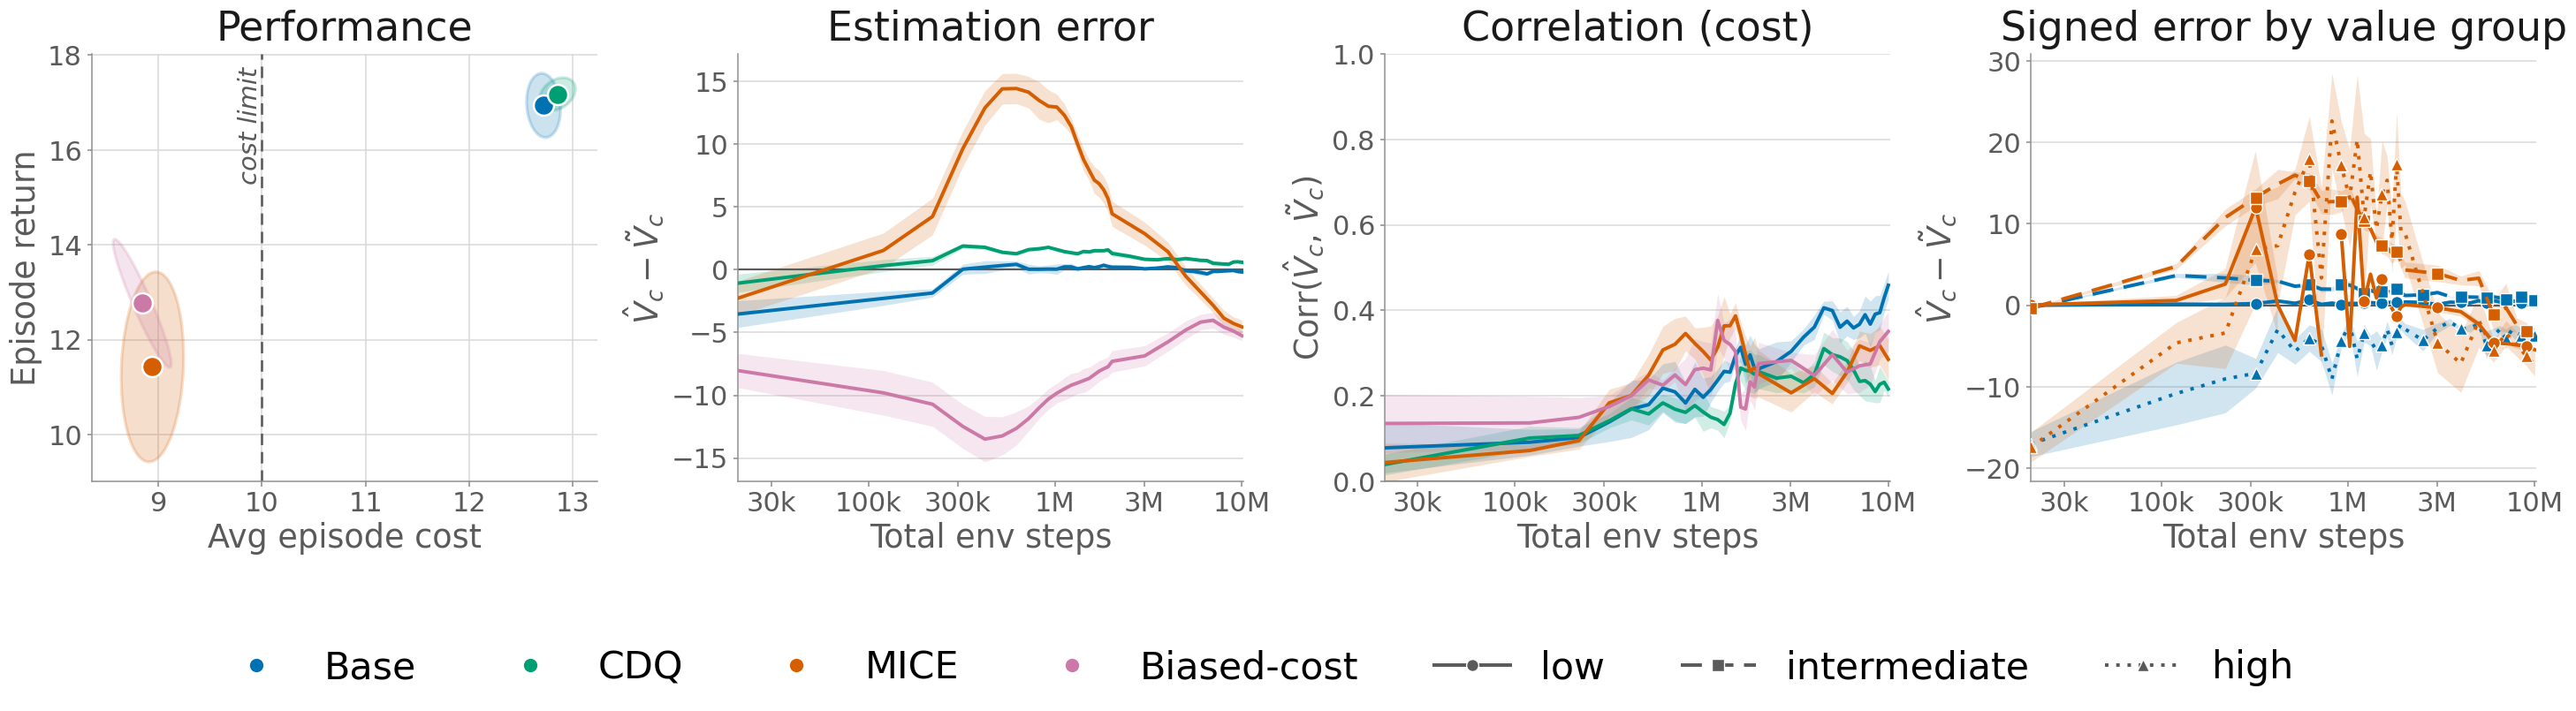

In [66]:
FIG = {
    "perf_xlim": None, "perf_ylim": None,     # None -> from the data
    "err_ylim": None, "corr_ylim": (0., 1.0), "bin_ylim": None,
    "show_seeds": False,                        # per-seed dots behind the ellipses
    "legend_in": 0.85,
    "legend_ncol": 8,
    "bin_markevery": 3,        # draw a bin marker every Nth checkpoint, not on all ~30
    "limit_label_y": 0.97,     # height of the "cost limit" label, in axes fraction
    # PooledMC is logged only at eval checkpoints (~37 points), so no smoothing by default
    "smooth": 4,
}


def smooth(M, w):
    """Running mean along the last axis, edge-normalised."""
    if w <= 1:
        return M
    k = np.ones(w)
    num = np.apply_along_axis(lambda v: np.convolve(v, k, "same"), -1, M)
    return num / np.convolve(np.ones(M.shape[-1]), k, "same")


def seed_curves(name, col):
    """(steps, per-seed matrix) for one history column, NaNs dropped first.

    The PooledMC columns are logged only at eval checkpoints -- about 37 of a run's 512 rows
    -- so a run's column is mostly NaN.  Dropping those rows before aligning keeps the curve
    intact; carrying them through any windowed operation would erase it.
    """
    h = HIST[name].dropna(subset=[col, "TotalEnvSteps", "seed"])
    per = [g.sort_values("TotalEnvSteps") for _, g in h.groupby("seed")]
    steps = np.array(sorted(set.intersection(*[set(g.TotalEnvSteps) for g in per])))
    M = np.stack([np.interp(steps, g.TotalEnvSteps, g[col]) for g in per])
    return steps, M


def figure_comparison():
    fig, ax = make_axes(4, legend_in=FIG["legend_in"])
    L, ink = STYLE["line"], STYLE["ink"]

    # --- 1. final performance, one s.e. ellipse per method ---------------------------
    for name, _ in METHODS:
        sel = select_runs(SWEEPS[name], RUNS[name], BEST[name])
        x = (sel.TotalCost / (sel.TotalEnvSteps / sel.EpLen)).to_numpy()
        y = sel.EpRet.to_numpy()
        c = MCOLOR[name]
        if FIG["show_seeds"]:
            ax[0].scatter(x, y, s=L["seed_marker"] ** 2, color=c, alpha=L["seed_alpha"],
                          edgecolors="none", zorder=4)
        sem_ellipse(ax[0], x, y, c)
        ax[0].scatter(x.mean(), y.mean(), s=L["mean_marker"] ** 2, color=c,
                      edgecolor="white", linewidth=1.6, zorder=5)
    ax[0].axvline(COST_LIMIT, color=ink["rule"], lw=L["rule_width"], ls=L["rule_dash"],
                  zorder=2)
    ax[0].annotate(TEXT["cost_limit"], xy=(COST_LIMIT, FIG["limit_label_y"]),
                   xycoords=ax[0].get_xaxis_transform(), xytext=(-9, 0),
                   textcoords="offset points", rotation=90, ha="center", va="top",
                   fontsize=STYLE["font"]["note"], style="italic", color=ink["label"])
    ax[0].set_xlabel(TEXT["perf_x"])
    ax[0].set_ylabel(TEXT["perf_y"])
    ax[0].grid(True, axis="both", color=ink["grid"], lw=L["grid"])
    if FIG["perf_xlim"]:
        ax[0].set_xlim(*FIG["perf_xlim"])
    if FIG["perf_ylim"]:
        ax[0].set_ylim(*FIG["perf_ylim"])

    # --- 2. estimation error, pred - true --------------------------------------------
    for name, _ in METHODS:
        # the logged PooledMC/EstimationError_c is (true - pred); negate for (pred - true)
        steps, M = seed_curves(name, "PooledMC/EstimationError_c")
        band(ax[1], steps, smooth(-M, FIG["smooth"]), MCOLOR[name])
    ax[1].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
    ax[1].set_ylabel(TEXT["err_y"])
    if FIG["err_ylim"]:
        ax[1].set_ylim(*FIG["err_ylim"])

    # --- 3. correlation ---------------------------------------------------------------
    for name, _ in METHODS:
        steps, M = seed_curves(name, "PooledMC/Correlation_c")
        band(ax[2], steps, smooth(M, FIG["smooth"]), MCOLOR[name])
    ax[2].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
    ax[2].set_ylabel(TEXT["corr_y"])
    if FIG["corr_ylim"]:
        ax[2].set_ylim(*FIG["corr_ylim"])

    # --- 4. signed error by value bin, Base vs MICE ----------------------------------
    for name in BIN_METHODS:
        p = PROBE[name]
        E = np.array([[signed_error_by_bin(p["pred"][s, t], p["G"][s, t])
                       for t in range(len(p["steps"]))] for s in range(p["pred"].shape[0])])
        for b, ls in enumerate(STYLE["bin_style"]):
            band(ax[3], p["steps"], E[:, :, b], MCOLOR[name], ls=ls,
                 marker=STYLE["bin_marker"][b], markevery=FIG["bin_markevery"])
    ax[3].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
    ax[3].set_ylabel(TEXT["bin_y"])
    if FIG["bin_ylim"]:
        ax[3].set_ylim(*FIG["bin_ylim"])

    for a in ax[1:]:
        log_steps(a, X_FIRST, X_LAST)
    for a, t in zip(ax, TEXT["titles"]):
        a.set_title(t)

    legend_below(fig,
                 [(dot_key(MCOLOR[n]), n) for n, _ in METHODS]
                 + [(line_key(ink["rule"], ls=STYLE["bin_style"][b],
                                marker=STYLE["bin_marker"][b]), TEXT["bins"][b])
                    for b in range(3)],
                 ncol=FIG["legend_ncol"])
    return fig


save(figure_comparison(), f"method_comparison_{SELECT_METRIC}")
show(f"method_comparison_{SELECT_METRIC}")

### 5.1 Signed error by bin — faceted

Column 4 above puts six curves on one axis, distinguished only by line style, and the three
bins differ by an order of magnitude — the low bin sits near 0 while the high bin swings
between -20 and +25, so the low bin is flattened into the zero line and the dashed/dotted
curves cross constantly.

This splits the same data into one panel per bin: **two** curves each, colour still meaning
the method, and each panel free to scale to its own bin. Nothing is smoothed or re-binned —
only the layout changes.

In [ ]:
BINFIG = {
    "ylim": None,          # None -> per-panel autoscale; or a list of three (lo, hi)
    "legend_in": 0.75,
    "zero_rule": True,
    "titles": None,        # None -> TEXT["bins"]; the definitions stay in TEXT["bin_defs"]
}


def bin_errors(name):
    """(steps, array (seeds, checkpoints, 3)) of mean signed error per value bin."""
    p = PROBE[name]
    E = np.array([[signed_error_by_bin(p["pred"][s, t], p["G"][s, t])
                   for t in range(len(p["steps"]))]
                  for s in range(p["pred"].shape[0])])
    return p["steps"], E


def figure_bins_faceted():
    titles = BINFIG["titles"] or TEXT["bins"]
    fig, ax = make_axes(3, legend_in=BINFIG["legend_in"])
    ink = STYLE["ink"]

    curves = {name: bin_errors(name) for name in BIN_METHODS}
    for b in range(3):
        for name in BIN_METHODS:
            steps, E = curves[name]
            band(ax[b], steps, E[:, :, b], MCOLOR[name])
        if BINFIG["zero_rule"]:
            ax[b].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
        ax[b].set_title(titles[b])
        log_steps(ax[b], X_FIRST, X_LAST)
        if BINFIG["ylim"]:
            ax[b].set_ylim(*BINFIG["ylim"][b])
    ax[0].set_ylabel(TEXT["bin_y"])

    # Just the two methods: the panel titles already name the bins, and their definitions
    # are in the markdown above -- packing them into the legend collided with the x labels.
    legend_below(fig, [(line_key(MCOLOR[n]), n) for n in BIN_METHODS], ncol=2, y=0.02)
    return fig


save(figure_bins_faceted(), "signed_error_by_bin")
show("signed_error_by_bin")

# final-value readout, so the panels can be checked against numbers
for name in BIN_METHODS:
    steps, E = bin_errors(name)
    last = np.nanmean(E[:, -1, :], 0)
    print(f"  {name:6s} final signed error  "
          + "  ".join(f"{TEXT['bins'][b]}: {last[b]:+.2f}" for b in range(3)))

### 5.2 Alternative 1x4 — column 4 coloured by bin

The same four columns as the main figure, but with column 4's encodings swapped: **colour is
the value bin** (the ordered low → intermediate → high palette from `critic_figures.ipynb`)
and **line style is the method** — dotted Base, solid MICE.

This is a separate figure, saved under its own name; the main comparison above is unchanged,
so the two encodings can be compared side by side.

Note the trade-off: colour means *method* in columns 1–3 and *bin* in column 4, so the legend
carries two rows. The main figure keeps colour meaning method throughout instead.

In [ ]:
FIG_ALT = {
    # ordered low -> high, the same palette as critic_figures.ipynb
    "group_colors": ["#bdbdbd", "#9e9ac8", "#c44e52"],
    "method_style": {"Base": (0, (1, 2.2)), "MICE": "-"},      # dotted / solid
    "perf_xlim": None, "perf_ylim": None,
    "err_ylim": None, "corr_ylim": (-0.1, 1.0), "bin_ylim": None,
    "show_seeds": True,
    "limit_label_y": 0.97,
    "legend_in": 1.55,        # two legend rows
    "legend_ncol": 5,
}


def figure_comparison_alt():
    gcols, mstyle = FIG_ALT["group_colors"], FIG_ALT["method_style"]
    fig, ax = make_axes(4, legend_in=FIG_ALT["legend_in"])
    L, ink = STYLE["line"], STYLE["ink"]

    # --- 1. final performance -----------------------------------------------------
    for name, _ in METHODS:
        sel = select_runs(SWEEPS[name], RUNS[name], BEST[name])
        x = (sel.TotalCost / (sel.TotalEnvSteps / sel.EpLen)).to_numpy()
        y = sel.EpRet.to_numpy()
        c = MCOLOR[name]
        if FIG_ALT["show_seeds"]:
            ax[0].scatter(x, y, s=L["seed_marker"] ** 2, color=c, alpha=L["seed_alpha"],
                          edgecolors="none", zorder=4)
        sem_ellipse(ax[0], x, y, c)
        ax[0].scatter(x.mean(), y.mean(), s=L["mean_marker"] ** 2, color=c,
                      edgecolor="white", linewidth=1.6, zorder=5)
    ax[0].axvline(COST_LIMIT, color=ink["rule"], lw=L["rule_width"], ls=L["rule_dash"],
                  zorder=2)
    ax[0].annotate(TEXT["cost_limit"], xy=(COST_LIMIT, FIG_ALT["limit_label_y"]),
                   xycoords=ax[0].get_xaxis_transform(), xytext=(-9, 0),
                   textcoords="offset points", rotation=90, ha="center", va="top",
                   fontsize=STYLE["font"]["note"], style="italic", color=ink["label"])
    ax[0].set_xlabel(TEXT["perf_x"])
    ax[0].set_ylabel(TEXT["perf_y"])
    ax[0].grid(True, axis="both", color=ink["grid"], lw=L["grid"])
    if FIG_ALT["perf_xlim"]:
        ax[0].set_xlim(*FIG_ALT["perf_xlim"])
    if FIG_ALT["perf_ylim"]:
        ax[0].set_ylim(*FIG_ALT["perf_ylim"])

    # --- 2. estimation error (logged value is true - pred, so negate) ---------------
    for name, _ in METHODS:
        steps, M = seed_curves(name, "PooledMC/EstimationError_c")
        band(ax[1], steps, -M, MCOLOR[name])
    ax[1].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
    ax[1].set_ylabel(TEXT["err_y"])
    if FIG_ALT["err_ylim"]:
        ax[1].set_ylim(*FIG_ALT["err_ylim"])

    # --- 3. correlation --------------------------------------------------------------
    for name, _ in METHODS:
        steps, M = seed_curves(name, "PooledMC/Correlation_c")
        band(ax[2], steps, M, MCOLOR[name])
    ax[2].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
    ax[2].set_ylabel(TEXT["corr_y"])
    if FIG_ALT["corr_ylim"]:
        ax[2].set_ylim(*FIG_ALT["corr_ylim"])

    # --- 4. signed error by bin: colour = bin, line style = method -------------------
    for name in BIN_METHODS:
        steps, E = bin_errors(name)
        for b, gc in enumerate(gcols):
            band(ax[3], steps, E[:, :, b], gc, ls=mstyle[name])
    ax[3].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
    ax[3].set_ylabel(TEXT["bin_y"])
    if FIG_ALT["bin_ylim"]:
        ax[3].set_ylim(*FIG_ALT["bin_ylim"])

    for a in ax[1:]:
        log_steps(a, X_FIRST, X_LAST)
    for a, t in zip(ax, TEXT["titles"]):
        a.set_title(t)

    # row 1: methods (columns 1-3).  row 2: column 4's own encoding.
    legend_below(fig,
                 [(dot_key(MCOLOR[n]), n) for n, _ in METHODS]
                 + [(line_key(gcols[b]), TEXT["bins"][b]) for b in range(3)]
                 + [(line_key(ink["rule"], ls=mstyle[n]), n) for n in BIN_METHODS],
                 ncol=FIG_ALT["legend_ncol"])
    return fig


save(figure_comparison_alt(), f"method_comparison_{SELECT_METRIC}_bincolour")
show(f"method_comparison_{SELECT_METRIC}_bincolour")

### 5.3 Same figure, legend split into labelled groups

The single row of seven keys mixes two different encodings — four methods (colour, columns
1–3) and three value bins (line style and marker, column 4). This splits them into two
bracketed groups with headings, so it is obvious which key belongs to which panel.

It reuses `figure_comparison()` and only replaces the legend, so the panels are identical to
the main figure above.

In [ ]:
LEGEND2 = {
    "style": "brackets",        # "brackets" | "box" | "none"
    "headings": ["Method", "Value group"],
    "x": None,                  # None -> measured auto-layout, centred as a pair
    "group_gap": 0.055,         # gap between the two groups, in figure widths
    "y": 0.010,
    "legend_in": 2.30,          # headings need a little more room than one plain row
    "bracket_color": "#b0b0b0",
    "bracket_lw": 1.8,
    "bracket_pad": 0.008,       # gap between the legend box and its bracket
    "bracket_arm": 0.007,       # length of the bracket's horizontal arms
    "heading_size": None,       # None -> STYLE["font"]["legend"]
}


def bracket(fig, bbox, cfg):
    """Draw [ ] around a bbox given in figure coordinates."""
    pad, arm = cfg["bracket_pad"], cfg["bracket_arm"]
    kw = dict(color=cfg["bracket_color"], lw=cfg["bracket_lw"],
              transform=fig.transFigure, zorder=5, solid_capstyle="round")
    for x, direction in ((bbox.x0 - pad, +1), (bbox.x1 + pad, -1)):
        fig.add_artist(Line2D([x, x], [bbox.y0, bbox.y1], **kw))
        for y in (bbox.y0, bbox.y1):
            fig.add_artist(Line2D([x, x + direction * arm], [y, y], **kw))


def grouped_legend(fig, groups, cfg):
    """One small legend per group, each with a heading and a bracket around it."""
    size = cfg["heading_size"] or STYLE["font"]["legend"]
    xs = cfg["x"] or [0.5] * len(groups)      # provisional; measured and fixed up below
    legs = []
    for (heading, entries), x in zip(groups, xs):
        leg = fig.legend([h for h, _ in entries], [l for _, l in entries],
                         loc="lower center", bbox_to_anchor=(x, cfg["y"]),
                         ncol=len(entries), frameon=(cfg["style"] == "box"),
                         fancybox=True, edgecolor=STYLE["ink"]["grid"],
                         facecolor="white", title=heading,
                         fontsize=STYLE["font"]["legend"], title_fontsize=size)
        leg.get_title().set_fontweight("bold")
        leg.get_title().set_color(STYLE["ink"]["title"])
        legs.append(leg)

    # Lay the groups out from their measured widths rather than guessed positions: at this
    # font size a fixed x collides as soon as an entry label gets longer.
    if cfg["x"] is None:
        fig.canvas.draw()
        inv = fig.transFigure.inverted()
        widths = [leg.get_window_extent().transformed(inv).width for leg in legs]
        gap = cfg["group_gap"]
        total = sum(widths) + gap * (len(legs) - 1)
        if total > 1.0:
            print(f"  legend groups need {total:.2f} of the figure width; "
                  f"reduce STYLE['font']['legend'] or set LEGEND2['x'] by hand")
        x = 0.5 - total / 2
        for leg, w in zip(legs, widths):
            leg.set_bbox_to_anchor((x + w / 2, cfg["y"]), transform=fig.transFigure)
            x += w + gap

    if cfg["style"] == "brackets":
        fig.canvas.draw()                       # extents are only valid once drawn
        inv = fig.transFigure.inverted()
        for leg in legs:
            bracket(fig, leg.get_window_extent().transformed(inv), cfg)


def figure_grouped_legend():
    prev = FIG["legend_in"]
    FIG["legend_in"] = LEGEND2["legend_in"]
    try:
        fig = figure_comparison()               # identical panels; only the legend changes
    finally:
        FIG["legend_in"] = prev

    for leg in list(fig.legends):               # drop the single-row legend
        leg.remove()
    fig.legends.clear()

    ink = STYLE["ink"]
    grouped_legend(fig, [
        (LEGEND2["headings"][0], [(dot_key(MCOLOR[n]), n) for n, _ in METHODS]),
        (LEGEND2["headings"][1], [(line_key(ink["rule"], ls=STYLE["bin_style"][b],
                                            marker=STYLE["bin_marker"][b]), TEXT["bins"][b])
                                  for b in range(3)]),
    ], LEGEND2)
    return fig


save(figure_grouped_legend(), f"method_comparison_{SELECT_METRIC}_grouped")
show(f"method_comparison_{SELECT_METRIC}_grouped")

## 6. Which config each metric picks

The selection is not always stable across metrics; this table makes the choice explicit.

In [ ]:
rows = []
for name, sid in METHODS:
    scores = SCORES[name]
    for metric in ("ratio", "EpRet", "avg_ep_cost"):
        b = best_config(scores, metric)
        rows.append(dict(method=name, metric=metric,
                         config=", ".join(f"{k}={b[k]}" for k in scores.attrs["keys"]),
                         EpRet=round(float(b.EpRet), 2),
                         avg_ep_cost=round(float(b.avg_ep_cost), 2),
                         ratio=round(float(b.ratio), 3), n_seeds=int(b.n_seeds)))
table = pd.DataFrame(rows)
try:
    display(table)
except NameError:
    print(table.to_string(index=False))

## 7. Output

In [ ]:
for p in sorted(FIG_DIR.iterdir()):
    print(f"{p.stat().st_size / 1e3:8.1f} kB  {p.name}")